In [ ]:
# u2855208
# Abdul Hadi
# Dissertation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = "/content/drive/MyDrive/DS7010_HousePrices"
for p in ["data/raw", "data/processed", "outputs", "src", "notebooks"]:
    os.makedirs(os.path.join(BASE, p), exist_ok=True)

print("Created/checked folders at:", BASE)

Mounted at /content/drive
Created/checked folders at: /content/drive/MyDrive/DS7010_HousePrices


In [ ]:
import os
RAW = "/content/drive/MyDrive/DS7010_HousePrices/data/raw"
print(os.listdir(RAW))

['pp-2024.csv', 'pp-2023.csv', 'pp-2022.csv']


In [ ]:
import os
import pandas as pd

RAW  = "/content/drive/MyDrive/DS7010_HousePrices/data/raw"
PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"

# PPD has NO headers, so I assign column names (standard PPD layout)
ppd_cols = [
    "transaction_id","price","date_of_transfer","postcode",
    "property_type","new_build_flag","tenure_type",
    "paon","saon","street","locality","town_city","district","county",
    "ppd_category_type","record_status"
]

# Keep only columns I need for modelling
keep_cols = ["price","date_of_transfer","postcode","property_type","new_build_flag","tenure_type"]

def load_one_year(path):
    df = pd.read_csv(path, header=None, names=ppd_cols, usecols=keep_cols, dtype={"postcode":"string"})
    # basic cleaning
    df["date_of_transfer"] = pd.to_datetime(df["date_of_transfer"], errors="coerce")
    df["postcode"] = df["postcode"].str.strip().str.upper()
    df = df.dropna(subset=["price","date_of_transfer","postcode"])
    df = df[df["price"] > 0]
    return df

files = ["pp-2022.csv", "pp-2023.csv", "pp-2024.csv"]
ppd_all = pd.concat([load_one_year(os.path.join(RAW, f)) for f in files], ignore_index=True)

out_path = os.path.join(PROC, "ppd_2022_2024_min.csv")
ppd_all.to_csv(out_path, index=False)

print("Saved:", out_path)
print("Rows, Cols:", ppd_all.shape)
ppd_all.head()

Saved: /content/drive/MyDrive/DS7010_HousePrices/data/processed/ppd_2022_2024_min.csv
Rows, Cols: (2847476, 6)


,price,date_of_transfer,postcode,property_type,new_build_flag,tenure_type
0,280000,2022-06-06,B78 3XA,D,N,F
1,312500,2022-06-20,ST7 4JZ,D,N,F
2,150000,2022-06-30,ST14 7QG,S,N,F
3,515000,2022-05-25,B78 3UG,D,N,F
4,262500,2022-07-15,ST20 0HY,D,N,F


In [ ]:
import os
RAW = "/content/drive/MyDrive/DS7010_HousePrices/data/raw"
[x for x in os.listdir(RAW) if "ONSPD" in x.upper()]

['ONSPD_AUG_2025_UK.csv']

In [ ]:
import os
import pandas as pd

RAW  = "/content/drive/MyDrive/DS7010_HousePrices/data/raw"
PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"

onspd_path = os.path.join(RAW, "ONSPD_AUG_2025_UK.csv")

# Read only the header first (0 rows) to see column names
cols = pd.read_csv(onspd_path, nrows=0).columns.tolist()
print("Total columns in ONSPD:", len(cols))

# Find the key columns we need
pc_col   = "pcds" if "pcds" in cols else ("pcd" if "pcd" in cols else None)
lat_col  = "lat" if "lat" in cols else None
lon_col  = "long" if "long" in cols else ("lon" if "lon" in cols else None)

#  Use lsoa11 if available, otherwise fall back to the first column starting with "lsoa"

lsoa_col = "lsoa11" if "lsoa11" in cols else next((c for c in cols if c.lower().startswith("lsoa")), None)

print("Using columns:", pc_col, lat_col, lon_col, lsoa_col)

# Load only these columns
usecols = [pc_col, lat_col, lon_col, lsoa_col]
onspd = pd.read_csv(onspd_path, usecols=usecols, dtype={pc_col: "string"})

# Clean postcode for joining
onspd[pc_col] = onspd[pc_col].str.strip().str.upper()

# Rename to standard names
onspd = onspd.rename(columns={pc_col: "postcode", lat_col: "lat", lon_col: "lon", lsoa_col: "lsoa"})
onspd = onspd.dropna(subset=["postcode", "lat", "lon", "lsoa"])

out_path = os.path.join(PROC, "onspd_min.csv")
onspd.to_csv(out_path, index=False)

print("Saved:", out_path)
print("Rows, Cols:", onspd.shape)
onspd.head()

Total columns in ONSPD: 53
Using columns: pcds lat long lsoa01cd
Saved: /content/drive/MyDrive/DS7010_HousePrices/data/processed/onspd_min.csv
Rows, Cols: (2706777, 4)


,postcode,lsoa,lat,lon
0,AB1 0AA,S01000011,57.101459,-2.242858
1,AB1 0AB,S01000011,57.102539,-2.246315
2,AB1 0AD,S01000011,57.100541,-2.248349
3,AB1 0AE,S01000333,57.084429,-2.255714
4,AB1 0AF,S01000007,57.096641,-2.258109


In [ ]:
import pandas as pd
import os

PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"

ppd_path   = os.path.join(PROC, "ppd_2022_2024_min.csv")
onspd_path = os.path.join(PROC, "onspd_min.csv")

# Load both
ppd = pd.read_csv(ppd_path, dtype={"postcode": "string"})
onspd = pd.read_csv(onspd_path, dtype={"postcode": "string"})

# Clean postcodes again
ppd["postcode"] = ppd["postcode"].str.strip().str.upper()
onspd["postcode"] = onspd["postcode"].str.strip().str.upper()

# Merge: keep only rows that successfully match a postcode in ONSPD
merged = ppd.merge(onspd, on="postcode", how="inner")

# Save result
out_path = os.path.join(PROC, "ppd_onspd_2022_2024.csv")
merged.to_csv(out_path, index=False)

print("Saved:", out_path)
print("PPD rows:", len(ppd))
print("ONSPD rows:", len(onspd))
print("Merged rows:", len(merged))
merged.head()

Saved: /content/drive/MyDrive/DS7010_HousePrices/data/processed/ppd_onspd_2022_2024.csv
PPD rows: 2847476
ONSPD rows: 2706777
Merged rows: 2847166


,price,date_of_transfer,postcode,property_type,new_build_flag,tenure_type,lsoa,lat,lon
0,280000,2022-06-06,B78 3XA,D,N,F,E01029839,52.617397,-1.700116
1,312500,2022-06-20,ST7 4JZ,D,N,F,E01029582,53.107444,-2.207053
2,150000,2022-06-30,ST14 7QG,S,N,F,E01029430,52.904086,-1.889535
3,515000,2022-05-25,B78 3UG,D,N,F,E01029488,52.599563,-1.719358
4,262500,2022-07-15,ST20 0HY,D,N,F,E01029709,52.788000,-2.257516


In [ ]:
import pandas as pd
import os

PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"
path = os.path.join(PROC, "ppd_onspd_2022_2024.csv")

df = pd.read_csv(path, dtype={"postcode":"string"})

# London postcode areas (main ones)
london_prefixes = ("E", "EC", "N", "NW", "SE", "SW", "W", "WC")

london = df[df["postcode"].str.startswith(london_prefixes)].copy()

out_path = os.path.join(PROC, "ppd_london_2022_2024.csv")
london.to_csv(out_path, index=False)

print("Saved:", out_path)
print("London rows:", len(london))
london.head()

Saved: /content/drive/MyDrive/DS7010_HousePrices/data/processed/ppd_london_2022_2024.csv
London rows: 610152


,price,date_of_transfer,postcode,property_type,new_build_flag,tenure_type,lsoa,lat,lon
9,319950,2022-06-21,WS13 8SB,D,N,F,E01029479,52.721144,-1.766799
23,250000,2022-06-24,WS7 2BU,S,N,F,E01029490,52.681447,-1.930829
25,205000,2022-07-01,WS7 9EE,T,N,F,E01029507,52.678633,-1.904653
28,385000,2022-04-12,WS9 9EL,D,N,F,E01029523,52.632771,-1.897780
31,277000,2022-06-20,WA9 5GP,D,N,L,E01006912,53.437944,-2.723269


In [ ]:
import pandas as pd
import os

PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"
path = os.path.join(PROC, "ppd_onspd_2022_2024.csv")

df = pd.read_csv(path, dtype={"postcode":"string"})

# London-ish bounding box (quick, clean filter)
london = df[
    (df["lat"] >= 51.28) & (df["lat"] <= 51.72) &
    (df["lon"] >= -0.55) & (df["lon"] <= 0.35)
].copy()

out_path = os.path.join(PROC, "ppd_london_bbox_2022_2024.csv")
london.to_csv(out_path, index=False)

print("Saved:", out_path)
print("London bbox rows:", len(london))
print("Postcode examples:", london["postcode"].head(10).tolist())
london.head()

Saved: /content/drive/MyDrive/DS7010_HousePrices/data/processed/ppd_london_bbox_2022_2024.csv
London bbox rows: 391763
Postcode examples: ['W13 8PQ', 'UB1 2BT', 'UB2 5BY', 'N9 7NL', 'W7 2AT', 'W13 8PG', 'HA7 2EP', 'UB3 5HZ', 'N3 1EB', 'TW11 8SJ']


,price,date_of_transfer,postcode,property_type,new_build_flag,tenure_type,lsoa,lat,lon
62,1110000,2022-06-17,W13 8PQ,T,N,F,E01001227,51.515500,-0.317544
63,460000,2022-07-04,UB1 2BT,T,N,F,E01001297,51.520384,-0.376361
64,425000,2022-06-28,UB2 5BY,T,N,F,E01001366,51.502532,-0.393163
65,457000,2022-06-22,N9 7NL,T,N,F,E01001503,51.641781,-0.054572
66,985000,2022-06-22,W7 2AT,S,N,F,E01001299,51.499959,-0.328058


In [ ]:
import pandas as pd
import numpy as np
import os

PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"
path = os.path.join(PROC, "ppd_london_bbox_2022_2024.csv")

df = pd.read_csv(path, dtype={"postcode":"string"})

# to Make sure date is datetime
df["date_of_transfer"] = pd.to_datetime(df["date_of_transfer"], errors="coerce")

# Create features
df["log_price"] = np.log(df["price"])
df["year"] = df["date_of_transfer"].dt.year
df["month"] = df["date_of_transfer"].dt.month

# Quick sanity checks
print("Rows:", len(df))
print("Missing % (top):")
print((df.isna().mean()*100).sort_values(ascending=False).head(10))

print("\nPrice summary:")
print(df["price"].describe())

# Save model-ready version
out_path = os.path.join(PROC, "london_model_ready_2022_2024.csv")
df.to_csv(out_path, index=False)

print("\nSaved:", out_path)
df.head()

Rows: 391763
Missing % (top):
price               0.0
date_of_transfer    0.0
postcode            0.0
property_type       0.0
new_build_flag      0.0
tenure_type         0.0
lsoa                0.0
lat                 0.0
lon                 0.0
log_price           0.0
dtype: float64

Price summary:
count    3.917630e+05
mean     7.964194e+05
std      2.692844e+06
min      1.000000e+00
25%      3.630000e+05
50%      5.000000e+05
75%      7.400000e+05
max      4.290000e+08
Name: price, dtype: float64

Saved: /content/drive/MyDrive/DS7010_HousePrices/data/processed/london_model_ready_2022_2024.csv


,price,date_of_transfer,postcode,property_type,new_build_flag,tenure_type,lsoa,lat,lon,log_price,year,month
0,1110000,2022-06-17,W13 8PQ,T,N,F,E01001227,51.515500,-0.317544,13.919871,2022,6
1,460000,2022-07-04,UB1 2BT,T,N,F,E01001297,51.520384,-0.376361,13.038982,2022,7
2,425000,2022-06-28,UB2 5BY,T,N,F,E01001366,51.502532,-0.393163,12.959844,2022,6
3,457000,2022-06-22,N9 7NL,T,N,F,E01001503,51.641781,-0.054572,13.032439,2022,6
4,985000,2022-06-22,W7 2AT,S,N,F,E01001299,51.499959,-0.328058,13.800397,2022,6


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import os

PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"
path = os.path.join(PROC, "london_model_ready_2022_2024.csv")

df = pd.read_csv(path, dtype={"postcode":"string"})

# --- Outlier cleanup
# Keep prices between £10,000 and £10,000,000
df = df[(df["price"] >= 10_000) & (df["price"] <= 10_000_000)].copy()

# Recompute log_price after filtering
df["log_price"] = np.log(df["price"])

# --- Time-based split ---
train = df[df["year"].isin([2022, 2023])].copy()
test  = df[df["year"] == 2024].copy()

print("After outlier filter rows:", len(df))
print("Train rows (2022-2023):", len(train))
print("Test rows (2024):", len(test))
print("Train price range:", train["price"].min(), "to", train["price"].max())
print("Test price range:", test["price"].min(), "to", test["price"].max())

# Save splits
train_path = os.path.join(PROC, "train_2022_2023.csv")
test_path  = os.path.join(PROC, "test_2024.csv")
train.to_csv(train_path, index=False)
test.to_csv(test_path, index=False)

print("Saved:", train_path)
print("Saved:", test_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
After outlier filter rows: 388881
Train rows (2022-2023): 262997
Test rows (2024): 125884
Train price range: 10000 to 10000000
Test price range: 10000 to 10000000
Saved: /content/drive/MyDrive/DS7010_HousePrices/data/processed/train_2022_2023.csv
Saved: /content/drive/MyDrive/DS7010_HousePrices/data/processed/test_2024.csv


In [ ]:
#  step no 11:  Baseline Model (Elastic Net) + Evaluate on 2024
# Uses log_price as target, then converts predictions back to £ for MAE/RMSE

import os
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1) Load train/test files that I created in Step no 10
PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"
train_path = os.path.join(PROC, "train_2022_2023.csv")
test_path  = os.path.join(PROC, "test_2024.csv")

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

# 2) Choose baseline features
# Numeric features: coordinates + month
num_features = ["lat", "lon", "month"]

# Categorical features: property + flags
cat_features = ["property_type", "new_build_flag", "tenure_type"]

# 3) Split into X (features) and y (target)
X_train = train[num_features + cat_features]
y_train = train["log_price"]

X_test  = test[num_features + cat_features]
y_test  = test["log_price"]

# 4) Preprocess:
#  One-hot encode categorical columns (turn letters like D/S/T/F, Y/N into 0/1 columns)
# Pass numeric columns through unchanged
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", "passthrough", num_features),
    ]
)

# 5) Elastic Net baseline model
# alpha controls overall regularization strength
# l1_ratio controls mix of L1 (Lasso) and L2 (Ridge)
model = ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=5000)

# 6) Build pipeline: preprocess -> model
pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

# 7) Train
pipe.fit(X_train, y_train)

# 8) Predict (log space), then convert to pounds (£)
pred_log = pipe.predict(X_test)
pred_price = np.exp(pred_log)
true_price = np.exp(y_test)

# 9) Evaluate (in pounds)
mae = mean_absolute_error(true_price, pred_price)
mse = mean_squared_error(true_price, pred_price)
rmse = np.sqrt(mse)

print("Baseline ElasticNet results (Test = 2024)")
print("MAE (£):", round(mae, 2))
print("RMSE (£):", round(rmse, 2))

Baseline ElasticNet results (Test = 2024)
MAE (£): 308083.64
RMSE (£): 693481.83


In [ ]:
import os
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"
train_path = os.path.join(PROC, "train_2022_2023.csv")
test_path  = os.path.join(PROC, "test_2024.csv")

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

num_features = ["lat", "lon", "month"]
cat_features = ["property_type", "new_build_flag", "tenure_type"]

X_train = train[num_features + cat_features]
y_train = train["log_price"]

X_test  = test[num_features + cat_features]
y_test  = test["log_price"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", "passthrough", num_features),
    ]
)

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_depth=None,
    min_samples_leaf=5
)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf)
])

pipe.fit(X_train, y_train)

pred_log = pipe.predict(X_test)
pred_price = np.exp(pred_log)
true_price = np.exp(y_test)

mae = mean_absolute_error(true_price, pred_price)
rmse = np.sqrt(mean_squared_error(true_price, pred_price))

print("Random Forest results (Test = 2024)")
print("MAE (£):", round(mae, 2))
print("RMSE (£):", round(rmse, 2))

Random Forest results (Test = 2024)
MAE (£): 194503.68
RMSE (£): 506390.8


In [ ]:
import os
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"
train_path = os.path.join(PROC, "train_2022_2023.csv")
test_path  = os.path.join(PROC, "test_2024.csv")

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

num_features = ["lat", "lon", "month"]
cat_features = ["property_type", "new_build_flag", "tenure_type"]

X_train = train[num_features + cat_features]
y_train = train["log_price"]
X_test  = test[num_features + cat_features]
y_test  = test["log_price"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", "passthrough", num_features),
    ]
)

gbr = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=10,
    max_iter=300,
    random_state=42
)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", gbr)
])

pipe.fit(X_train, y_train)

pred_log = pipe.predict(X_test)
pred_price = np.exp(pred_log)
true_price = np.exp(y_test)

mae = mean_absolute_error(true_price, pred_price)
rmse = np.sqrt(mean_squared_error(true_price, pred_price))

print("HistGradientBoosting results (Test = 2024)")
print("MAE (£):", round(mae, 2))
print("RMSE (£):", round(rmse, 2))

HistGradientBoosting results (Test = 2024)
MAE (£): 222999.23
RMSE (£): 559649.13


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
RAW = "/content/drive/MyDrive/DS7010_HousePrices/data/raw"
[x for x in os.listdir(RAW) if "IMD2019" in x.upper() or "FILE_1" in x.upper() or x.lower().endswith(".xlsx")]

Mounted at /content/drive


['File_1_-_IMD2019_Index_of_Multiple_Deprivation.xlsx']

In [ ]:
import os
import pandas as pd

RAW  = "/content/drive/MyDrive/DS7010_HousePrices/data/raw"
PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"

imd_path = os.path.join(RAW, "File_1_-_IMD2019_Index_of_Multiple_Deprivation.xlsx")

#read the correct sheet
imd = pd.read_excel(imd_path, sheet_name="IMD2019")

# Clean headers  (remove spaces/newlines)
imd.columns = imd.columns.astype(str).str.strip().str.replace("\n", " ", regex=False)

imd_min = imd[["LSOA code (2011)", "Index of Multiple Deprivation (IMD) Decile"]].copy()
imd_min.columns = ["lsoa", "imd_decile"]
imd_min["lsoa"] = imd_min["lsoa"].astype("string").str.strip().str.upper()

train = pd.read_csv(os.path.join(PROC, "train_2022_2023.csv"))
test  = pd.read_csv(os.path.join(PROC, "test_2024.csv"))

train["lsoa"] = train["lsoa"].astype("string").str.strip().str.upper()
test["lsoa"]  = test["lsoa"].astype("string").str.strip().str.upper()

train2 = train.merge(imd_min, on="lsoa", how="left")
test2  = test.merge(imd_min, on="lsoa", how="left")

print("Train missing IMD (%):", round(train2["imd_decile"].isna().mean()*100, 3))
print("Test missing IMD (%):", round(test2["imd_decile"].isna().mean()*100, 3))

train2_path = os.path.join(PROC, "train_2022_2023_imd.csv")
test2_path  = os.path.join(PROC, "test_2024_imd.csv")

train2.to_csv(train2_path, index=False)
test2.to_csv(test2_path, index=False)

print("Saved:", train2_path)
print("Saved:", test2_path)

train2[["lsoa","imd_decile"]].head()

Train missing IMD (%): 5.513
Test missing IMD (%): 5.838
Saved: /content/drive/MyDrive/DS7010_HousePrices/data/processed/train_2022_2023_imd.csv
Saved: /content/drive/MyDrive/DS7010_HousePrices/data/processed/test_2024_imd.csv


,lsoa,imd_decile
0,E01001227,8.0
1,E01001297,4.0
2,E01001366,3.0
3,E01001503,3.0
4,E01001299,9.0


In [ ]:
import os
import pandas as pd
import requests

RAW  = "/content/drive/MyDrive/DS7010_HousePrices/data/raw"

url = "https://api.tfl.gov.uk/StopPoint/Mode/tube,dlr,overground,elizabeth-line,tram"
r = requests.get(url)
r.raise_for_status()
data = r.json()

stops = pd.DataFrame([{
    "id": s.get("id"),
    "name": s.get("commonName"),
    "lat": s.get("lat"),
    "lon": s.get("lon"),
    "modes": ",".join(s.get("modes", []))
} for s in data.get("stopPoints", [])])

stops = stops.dropna(subset=["lat","lon"]).drop_duplicates(subset=["id"])

out_path = os.path.join(RAW, "tfl_stations_min.csv")
stops.to_csv(out_path, index=False)

print("Saved:", out_path)
print("Stations:", len(stops))
stops.head()

Saved: /content/drive/MyDrive/DS7010_HousePrices/data/raw/tfl_stations_min.csv
Stations: 2835


,id,name,lat,lon,modes
0,0400ZZLUAMS0,Amersham Underground Station,51.674206,-0.607362,tube
1,0400ZZLUCAL0,Chalfont & Latimer Underground Station,51.667915,-0.560616,tube
2,0400ZZLUCAL1,Chalfont & Latimer Underground Station,51.668122,-0.560624,tube
3,0400ZZLUCSM0,Chesham Underground Station,51.705227,-0.611113,tube
4,2100BUSHEY0,Bushey Rail Station,51.645628,-0.385600,overground


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree

RAW  = "/content/drive/MyDrive/DS7010_HousePrices/data/raw"
PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"

stations_path = os.path.join(RAW, "tfl_stations_min.csv")
train_path = os.path.join(PROC, "train_2022_2023_imd.csv")
test_path  = os.path.join(PROC, "test_2024_imd.csv")

stations = pd.read_csv(stations_path)
train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

# BallTree with haversine expects radians
stations_rad = np.deg2rad(stations[["lat", "lon"]].to_numpy())
tree = BallTree(stations_rad, metric="haversine")

def add_station_distance(df, tree):
    pts_rad = np.deg2rad(df[["lat", "lon"]].to_numpy())
    dist_rad, _ = tree.query(pts_rad, k=1)  # nearest station
    # Convert radians to km: Earth radius ~ 6371 km
    df["dist_station_km"] = dist_rad[:, 0] * 6371.0
    return df

train = add_station_distance(train, tree)
test  = add_station_distance(test, tree)

print("Train dist_station_km summary (km):")
print(train["dist_station_km"].describe())

print("\nTest dist_station_km summary (km):")
print(test["dist_station_km"].describe())

# Save updated files
train_out = os.path.join(PROC, "train_2022_2023_imd_tfl.csv")
test_out  = os.path.join(PROC, "test_2024_imd_tfl.csv")

train.to_csv(train_out, index=False)
test.to_csv(test_out, index=False)

print("\nSaved:", train_out)
print("Saved:", test_out)

train[["lat","lon","dist_station_km"]].head()

Train dist_station_km summary (km):
count    262997.000000
mean          2.403918
std           3.446878
min           0.002645
25%           0.435658
50%           0.893623
75%           2.663244
max          25.973832
Name: dist_station_km, dtype: float64

Test dist_station_km summary (km):
count    125884.000000
mean          2.402955
std           3.446155
min           0.001609
25%           0.441454
50%           0.902297
75%           2.670105
max          25.854441
Name: dist_station_km, dtype: float64

Saved: /content/drive/MyDrive/DS7010_HousePrices/data/processed/train_2022_2023_imd_tfl.csv
Saved: /content/drive/MyDrive/DS7010_HousePrices/data/processed/test_2024_imd_tfl.csv


,lat,lon,dist_station_km
0,51.515500,-0.317544,0.285057
1,51.520384,-0.376361,1.602962
2,51.502532,-0.393163,1.076865
3,51.641781,-0.054572,0.720028
4,51.499959,-0.328058,0.520377


In [ ]:
import os
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"
train_path = os.path.join(PROC, "train_2022_2023_imd_tfl.csv")
test_path  = os.path.join(PROC, "test_2024_imd_tfl.csv")

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

# Features (upgraded)
num_features = ["lat", "lon", "month", "imd_decile", "dist_station_km"]
cat_features = ["property_type", "new_build_flag", "tenure_type"]

X_train = train[num_features + cat_features]
y_train = train["log_price"]
X_test  = test[num_features + cat_features]
y_test  = test["log_price"]

# Preprocess:
#  Impute missing numeric values (IMD missing ~5-6%) with median
# One-hot encode categorical
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

def metrics_from_log(y_log_true, y_log_pred):
    true_price = np.exp(y_log_true)
    pred_price = np.exp(y_log_pred)

    mae = mean_absolute_error(true_price, pred_price)
    rmse = np.sqrt(mean_squared_error(true_price, pred_price))
    r2 = r2_score(true_price, pred_price)
    medae = median_absolute_error(true_price, pred_price)
    within10 = np.mean(np.abs(pred_price - true_price) <= 0.10 * true_price) * 100

    return mae, rmse, r2, medae, within10

def run_model(name, model):
    pipe = Pipeline(steps=[("preprocess", preprocess),
                          ("model", model)])
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)

    mae, rmse, r2, medae, within10 = metrics_from_log(y_test, pred_log)

    print(f"\n{name} (Test=2024)")
    print("MAE (£):", round(mae, 2))
    print("RMSE (£):", round(rmse, 2))
    print("R2:", round(r2, 4))
    print("MedianAE (£):", round(medae, 2))
    print("Within10% (%):", round(within10, 2))

# Model 1: ElasticNet baseline
run_model("ElasticNet", ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=5000))

# Model 2: Random Forest
run_model("RandomForest", RandomForestRegressor(
    n_estimators=300, random_state=42, n_jobs=-1, min_samples_leaf=5
))

# Model 3: HistGradientBoosting
run_model("HistGradientBoosting", HistGradientBoostingRegressor(
    learning_rate=0.05, max_depth=10, max_iter=300, random_state=42
))


ElasticNet (Test=2024)
MAE (£): 295797.61
RMSE (£): 677777.36
R2: 0.0644
MedianAE (£): 151098.45
Within10% (%): 17.2

RandomForest (Test=2024)
MAE (£): 193355.76
RMSE (£): 507553.21
R2: 0.4753
MedianAE (£): 81035.96
Within10% (%): 33.11

HistGradientBoosting (Test=2024)
MAE (£): 218892.99
RMSE (£): 554893.09
R2: 0.3729
MedianAE (£): 96981.36
Within10% (%): 27.88


In [ ]:
import os
import numpy as np
import pandas as pd

PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"

train_path = os.path.join(PROC, "train_2022_2023_imd_tfl.csv")
test_path  = os.path.join(PROC, "test_2024_imd_tfl.csv")

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

# Central London reference point (Charing Cross approx)
CENTER_LAT = 51.5074
CENTER_LON = -0.1278

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1 = np.deg2rad(lat1); lon1 = np.deg2rad(lon1)
    lat2 = np.deg2rad(lat2); lon2 = np.deg2rad(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

train["dist_center_km"] = haversine_km(train["lat"].values, train["lon"].values, CENTER_LAT, CENTER_LON)
test["dist_center_km"]  = haversine_km(test["lat"].values,  test["lon"].values,  CENTER_LAT, CENTER_LON)

print("Train dist_center_km summary:")
print(train["dist_center_km"].describe())

print("\nTest dist_center_km summary:")
print(test["dist_center_km"].describe())

train_out = os.path.join(PROC, "train_2022_2023_imd_tfl_center.csv")
test_out  = os.path.join(PROC, "test_2024_imd_tfl_center.csv")

train.to_csv(train_out, index=False)
test.to_csv(test_out, index=False)

print("\nSaved:", train_out)
print("Saved:", test_out)

train[["lat","lon","dist_center_km"]].head()

Train dist_center_km summary:
count    262997.000000
mean         14.534856
std           7.887569
min           0.077589
25%           8.133430
50%          13.653234
75%          19.918006
max          40.890305
Name: dist_center_km, dtype: float64

Test dist_center_km summary:
count    125884.000000
mean         14.494220
std           7.878913
min           0.077589
25%           8.034548
50%          13.564083
75%          19.896292
max          40.890305
Name: dist_center_km, dtype: float64

Saved: /content/drive/MyDrive/DS7010_HousePrices/data/processed/train_2022_2023_imd_tfl_center.csv
Saved: /content/drive/MyDrive/DS7010_HousePrices/data/processed/test_2024_imd_tfl_center.csv


,lat,lon,dist_center_km
0,51.515500,-0.317544,13.161719
1,51.520384,-0.376361,17.260742
2,51.502532,-0.393163,18.374515
3,51.641781,-0.054572,15.776160
4,51.499959,-0.328058,13.885502


In [ ]:
import os
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"
train_path = os.path.join(PROC, "train_2022_2023_imd_tfl_center.csv")
test_path  = os.path.join(PROC, "test_2024_imd_tfl_center.csv")

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

# Features (now with dist_center_km)
num_features = ["lat", "lon", "month", "imd_decile", "dist_station_km", "dist_center_km"]
cat_features = ["property_type", "new_build_flag", "tenure_type"]

X_train = train[num_features + cat_features]
y_train = train["log_price"]
X_test  = test[num_features + cat_features]
y_test  = test["log_price"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

def metrics_from_log(y_log_true, y_log_pred):
    true_price = np.exp(y_log_true)
    pred_price = np.exp(y_log_pred)
    mae = mean_absolute_error(true_price, pred_price)
    rmse = np.sqrt(mean_squared_error(true_price, pred_price))
    r2 = r2_score(true_price, pred_price)
    medae = median_absolute_error(true_price, pred_price)
    within10 = np.mean(np.abs(pred_price - true_price) <= 0.10 * true_price) * 100
    return mae, rmse, r2, medae, within10

def run_model(name, model):
    pipe = Pipeline([("preprocess", preprocess),
                     ("model", model)])
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)
    mae, rmse, r2, medae, within10 = metrics_from_log(y_test, pred_log)

    print(f"\n{name} (Test=2024)")
    print("MAE (£):", round(mae, 2))
    print("RMSE (£):", round(rmse, 2))
    print("R2:", round(r2, 4))
    print("MedianAE (£):", round(medae, 2))
    print("Within10% (%):", round(within10, 2))

run_model("ElasticNet", ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=5000))

run_model("RandomForest", RandomForestRegressor(
    n_estimators=300, random_state=42, n_jobs=-1, min_samples_leaf=5
))

run_model("HistGradientBoosting", HistGradientBoostingRegressor(
    learning_rate=0.05, max_depth=10, max_iter=300, random_state=42
))


ElasticNet (Test=2024)
MAE (£): 253574.29
RMSE (£): 623153.31
R2: 0.2091
MedianAE (£): 120989.18
Within10% (%): 22.13

RandomForest (Test=2024)
MAE (£): 192281.83
RMSE (£): 504103.52
R2: 0.4824
MedianAE (£): 80602.15
Within10% (%): 33.42

HistGradientBoosting (Test=2024)
MAE (£): 217327.58
RMSE (£): 546293.66
R2: 0.3922
MedianAE (£): 97203.42
Within10% (%): 27.77


In [ ]:
import time
import os
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor

PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"
train = pd.read_csv(os.path.join(PROC, "train_2022_2023_imd_tfl_center.csv"))

num_features = ["lat", "lon", "month", "imd_decile", "dist_station_km", "dist_center_km"]
cat_features = ["property_type", "new_build_flag", "tenure_type"]

X_train = train[num_features + cat_features]
y_train = train["log_price"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

model = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=10, random_state=42)
pipe = Pipeline([("preprocess", preprocess), ("model", model)])

t0 = time.time()
pipe.fit(X_train, y_train)
t1 = time.time()

print("One fit time (seconds):", round(t1 - t0, 2))

One fit time (seconds): 9.39


Saved predictions: /content/drive/MyDrive/DS7010_HousePrices/outputs/rf_preds_test_2024_final.csv


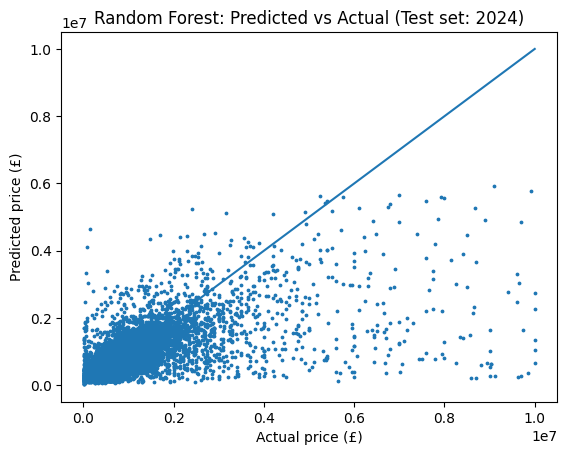

Saved figure: /content/drive/MyDrive/DS7010_HousePrices/outputs/figures/fig1_predicted_vs_actual_rf.png


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

# Paths
PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"
OUT  = "/content/drive/MyDrive/DS7010_HousePrices/outputs"
FIGS = os.path.join(OUT, "figures")
os.makedirs(FIGS, exist_ok=True)

train_path = os.path.join(PROC, "train_2022_2023_imd_tfl_center.csv")
test_path  = os.path.join(PROC, "test_2024_imd_tfl_center.csv")

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

# Features (final set)
num_features = ["lat", "lon", "month", "imd_decile", "dist_station_km", "dist_center_km"]
cat_features = ["property_type", "new_build_flag", "tenure_type"]

X_train = train[num_features + cat_features]
y_train = train["log_price"]

X_test  = test[num_features + cat_features]
y_test  = test["log_price"]

# Preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

# Best model
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=5
)

pipe = Pipeline([("preprocess", preprocess), ("model", rf)])
pipe.fit(X_train, y_train)

# Predict (convert log -> £)
pred_log = pipe.predict(X_test)
true_price = np.exp(y_test)
pred_price = np.exp(pred_log)

# Save predictions for later visualizations (residuals, maps, boxplots)
preds = test.copy()
preds["true_price"] = true_price
preds["pred_price"] = pred_price
preds["error"] = preds["pred_price"] - preds["true_price"]
preds["abs_error"] = np.abs(preds["error"])

preds_path = os.path.join(OUT, "rf_preds_test_2024_final.csv")
preds.to_csv(preds_path, index=False)
print("Saved predictions:", preds_path)

# Plot (sample for speed + clarity)
sample = preds.sample(n=min(30000, len(preds)), random_state=42)

plt.figure()
plt.scatter(sample["true_price"], sample["pred_price"], s=3)
plt.xlabel("Actual price (£)")
plt.ylabel("Predicted price (£)")
plt.title("Random Forest: Predicted vs Actual (Test set: 2024)")

# y = x reference line
mn = min(sample["true_price"].min(), sample["pred_price"].min())
mx = max(sample["true_price"].max(), sample["pred_price"].max())
plt.plot([mn, mx], [mn, mx])

fig_path = os.path.join(FIGS, "fig1_predicted_vs_actual_rf.png")
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)

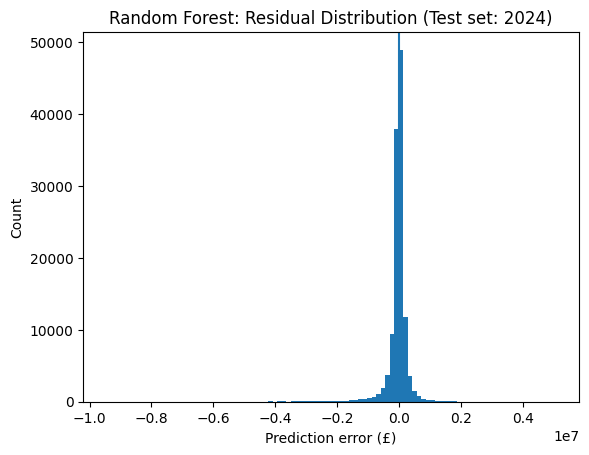

Saved figure: /content/drive/MyDrive/DS7010_HousePrices/outputs/figures/fig2_residual_distribution_rf.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

OUT  = "/content/drive/MyDrive/DS7010_HousePrices/outputs"
FIGS = os.path.join(OUT, "figures")

preds_path = os.path.join(OUT, "rf_preds_test_2024_final.csv")
preds = pd.read_csv(preds_path)

plt.figure()
plt.hist(preds["error"], bins=100)
plt.axvline(0)
plt.xlabel("Prediction error (£)")
plt.ylabel("Count")
plt.title("Random Forest: Residual Distribution (Test set: 2024)")

fig_path = os.path.join(FIGS, "fig2_residual_distribution_rf.png")
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)

price_band
<=300k       5.852402e+04
300k-600k    5.612274e+04
600k-1M      1.241080e+05
1M-2M        2.874883e+05
>2M          1.259402e+06
Name: abs_error, dtype: float64


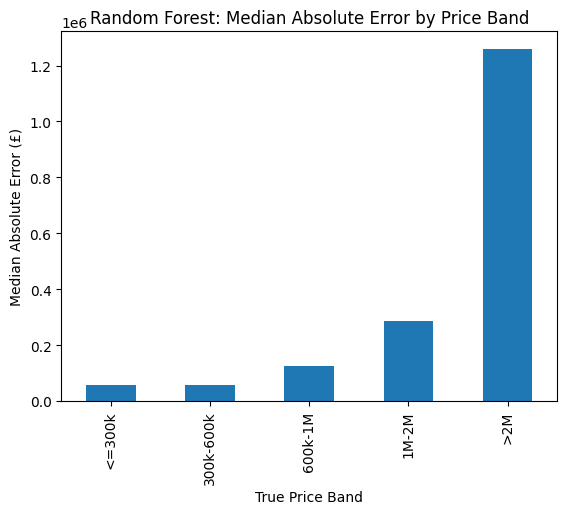

Saved figure: /content/drive/MyDrive/DS7010_HousePrices/outputs/figures/fig3_error_by_price_band_rf.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

OUT  = "/content/drive/MyDrive/DS7010_HousePrices/outputs"
FIGS = os.path.join(OUT, "figures")

preds_path = os.path.join(OUT, "rf_preds_test_2024_final.csv")
preds = pd.read_csv(preds_path)

# Create price bands based on true price
bins = [0, 300000, 600000, 1000000, 2000000, preds["true_price"].max()]
labels = ["<=300k", "300k-600k", "600k-1M", "1M-2M", ">2M"]

preds["price_band"] = pd.cut(preds["true_price"], bins=bins, labels=labels, include_lowest=True)
preds["abs_error"] = (preds["pred_price"] - preds["true_price"]).abs()

band_summary = preds.groupby("price_band", observed=False)["abs_error"].median()
print(band_summary)

plt.figure()
band_summary.plot(kind="bar")
plt.ylabel("Median Absolute Error (£)")
plt.xlabel("True Price Band")
plt.title("Random Forest: Median Absolute Error by Price Band")

fig_path = os.path.join(FIGS, "fig3_error_by_price_band_rf.png")
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)

           feature  importance_mean  importance_std
5   dist_center_km         0.258133        0.001863
8      tenure_type         0.205927        0.004344
1              lon         0.085135        0.001125
0              lat         0.068243        0.001469
6    property_type         0.063799        0.000857
3       imd_decile         0.052602        0.001314
4  dist_station_km         0.022951        0.000614
7   new_build_flag         0.008491        0.000811
2            month         0.000255        0.000397


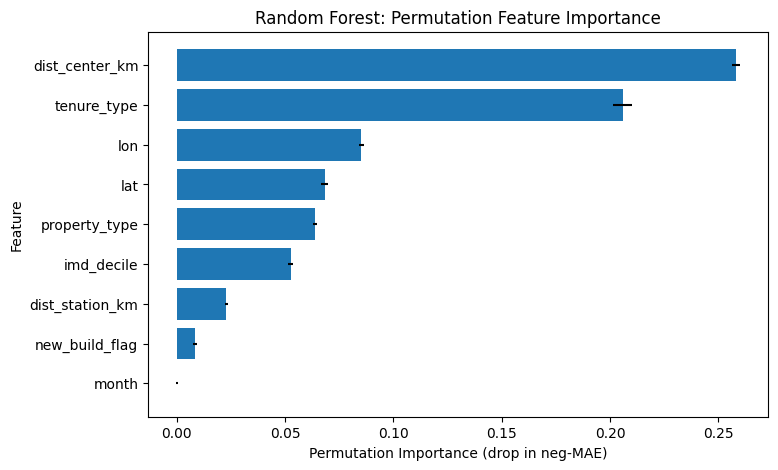

Saved figure: /content/drive/MyDrive/DS7010_HousePrices/outputs/figures/fig4_permutation_importance_rf.png


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# Paths
PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"
OUT  = "/content/drive/MyDrive/DS7010_HousePrices/outputs"
FIGS = os.path.join(OUT, "figures")
os.makedirs(FIGS, exist_ok=True)

# Load data
train = pd.read_csv(os.path.join(PROC, "train_2022_2023_imd_tfl_center.csv"))
test  = pd.read_csv(os.path.join(PROC, "test_2024_imd_tfl_center.csv"))

# Final feature set
num_features = ["lat", "lon", "month", "imd_decile", "dist_station_km", "dist_center_km"]
cat_features = ["property_type", "new_build_flag", "tenure_type"]
all_features = num_features + cat_features

X_train = train[all_features]
y_train = train["log_price"]

X_test = test[all_features]
y_test = test["log_price"]

# Preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

# Best model
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=5
)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", rf)
])

# Train model
pipe.fit(X_train, y_train)

# Smaller sample for permutation importance to avoid Colab storage/memory errors
sample_n = min(5000, len(X_test))
X_test_sample = X_test.sample(n=sample_n, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

# Permutation importance
perm = permutation_importance(
    pipe,
    X_test_sample,
    y_test_sample,
    n_repeats=3,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=1
)

importance_df = pd.DataFrame({
    "feature": all_features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print(importance_df)

# Plot
top_n = 10
plot_df = importance_df.head(top_n).sort_values("importance_mean")

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature"], plot_df["importance_mean"], xerr=plot_df["importance_std"])
plt.xlabel("Permutation Importance (drop in neg-MAE)")
plt.ylabel("Feature")
plt.title("Random Forest: Permutation Feature Importance")

fig_path = os.path.join(FIGS, "fig4_permutation_importance_rf.png")
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)

/tmp/ipykernel_5877/2694170553.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=order, showfliers=False)


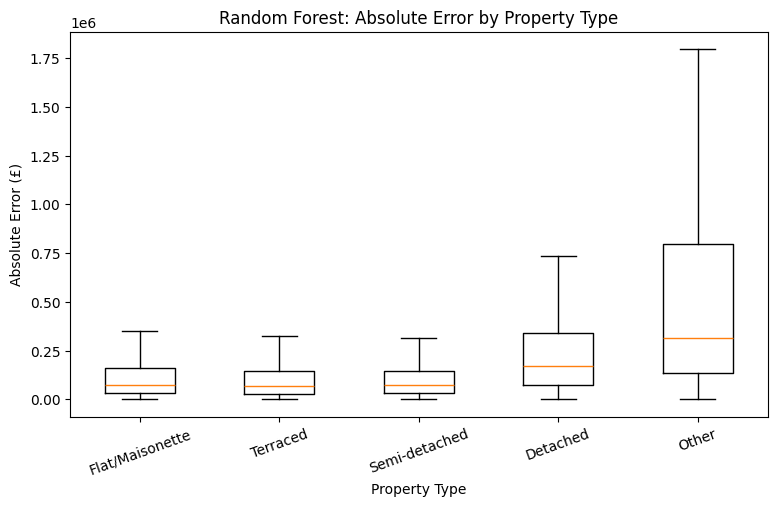

Saved figure: /content/drive/MyDrive/DS7010_HousePrices/outputs/figures/fig5_abs_error_by_property_type_rf.png

Median absolute error by property type:
property_type_label
Flat/Maisonette     75719.045560
Terraced            67000.331411
Semi-detached       72262.548707
Detached           168945.362877
Other              314167.090983
Name: abs_error, dtype: float64


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

OUT  = "/content/drive/MyDrive/DS7010_HousePrices/outputs"
FIGS = os.path.join(OUT, "figures")

preds_path = os.path.join(OUT, "rf_preds_test_2024_final.csv")
preds = pd.read_csv(preds_path)

# to keep the property type labels readable
type_map = {
    "D": "Detached",
    "S": "Semi-detached",
    "T": "Terraced",
    "F": "Flat/Maisonette",
    "O": "Other"
}

preds["property_type_label"] = preds["property_type"].map(type_map).fillna(preds["property_type"])

# Make sure abs_error exists
if "abs_error" not in preds.columns:
    preds["abs_error"] = (preds["pred_price"] - preds["true_price"]).abs()

#   cap extreme errors for a cleaner boxplot view
plot_data = preds.copy()
upper_cap = plot_data["abs_error"].quantile(0.99)
plot_data["abs_error_capped"] = plot_data["abs_error"].clip(upper=upper_cap)

# toOrder categories
order = ["Flat/Maisonette", "Terraced", "Semi-detached", "Detached", "Other"]
plot_data = plot_data[plot_data["property_type_label"].isin(order)]

data_to_plot = [
    plot_data.loc[plot_data["property_type_label"] == label, "abs_error_capped"]
    for label in order
]

plt.figure(figsize=(9, 5))
plt.boxplot(data_to_plot, labels=order, showfliers=False)
plt.xticks(rotation=20)
plt.ylabel("Absolute Error (£)")
plt.xlabel("Property Type")
plt.title("Random Forest: Absolute Error by Property Type")

fig_path = os.path.join(FIGS, "fig5_abs_error_by_property_type_rf.png")
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)

# Helpful summary table
summary = plot_data.groupby("property_type_label")["abs_error"].median().reindex(order)
print("\nMedian absolute error by property type:")
print(summary)

                 price  log_price    lat    lon  month  imd_decile  \
price            1.000      0.791  0.004 -0.102  0.002       0.168   
log_price        0.791      1.000  0.004 -0.134  0.016       0.229   
lat              0.004      0.004  1.000  0.064 -0.002      -0.188   
lon             -0.102     -0.134  0.064  1.000 -0.001      -0.183   
month            0.002      0.016 -0.002 -0.001  1.000      -0.002   
imd_decile       0.168      0.229 -0.188 -0.183 -0.002       1.000   
dist_station_km -0.069     -0.077 -0.508  0.047 -0.003       0.305   
dist_center_km  -0.223     -0.248 -0.065  0.050 -0.012       0.310   

                 dist_station_km  dist_center_km  
price                     -0.069          -0.223  
log_price                 -0.077          -0.248  
lat                       -0.508          -0.065  
lon                        0.047           0.050  
month                     -0.003          -0.012  
imd_decile                 0.305           0.310  
dist_station

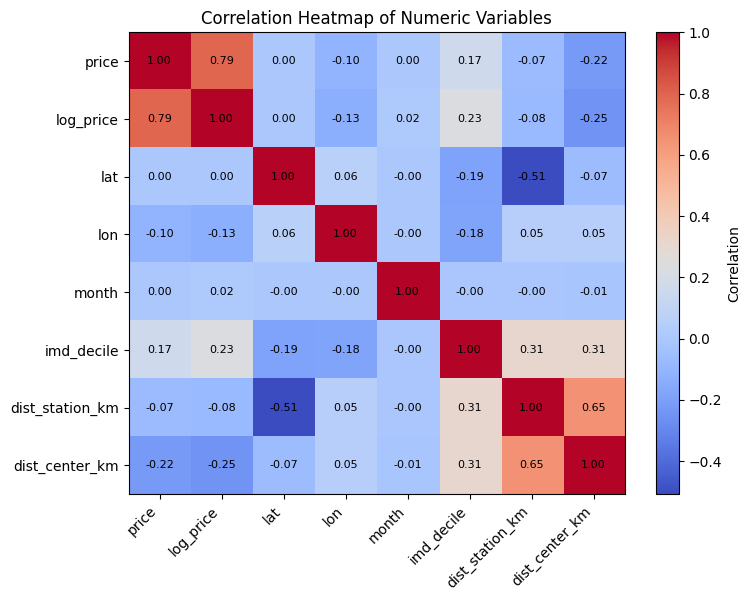

Saved figure: /content/drive/MyDrive/DS7010_HousePrices/outputs/figures/fig6_correlation_heatmap.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"
OUT  = "/content/drive/MyDrive/DS7010_HousePrices/outputs"
FIGS = os.path.join(OUT, "figures")
os.makedirs(FIGS, exist_ok=True)

# Load final modelling dataset
df = pd.read_csv(os.path.join(PROC, "train_2022_2023_imd_tfl_center.csv"))

# Select numeric columns for EDA
num_cols = [
    "price",
    "log_price",
    "lat",
    "lon",
    "month",
    "imd_decile",
    "dist_station_km",
    "dist_center_km"
]

corr = df[num_cols].corr(numeric_only=True)

print(corr.round(3))

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)

plt.title("Correlation Heatmap of Numeric Variables")

# Add correlation values inside cells
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig_path = os.path.join(FIGS, "fig6_correlation_heatmap.png")
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)

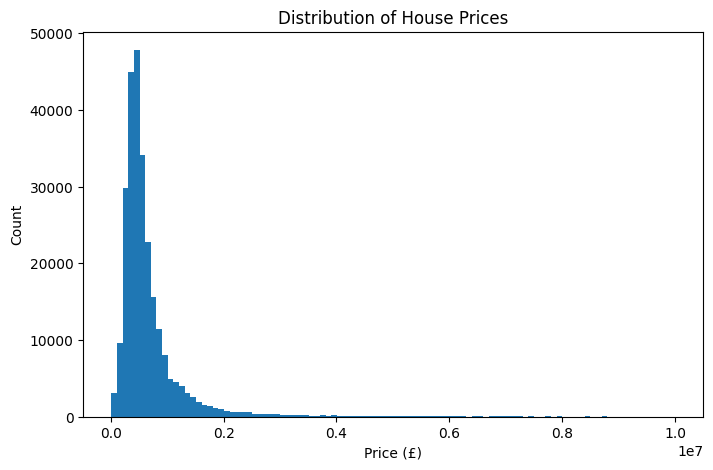

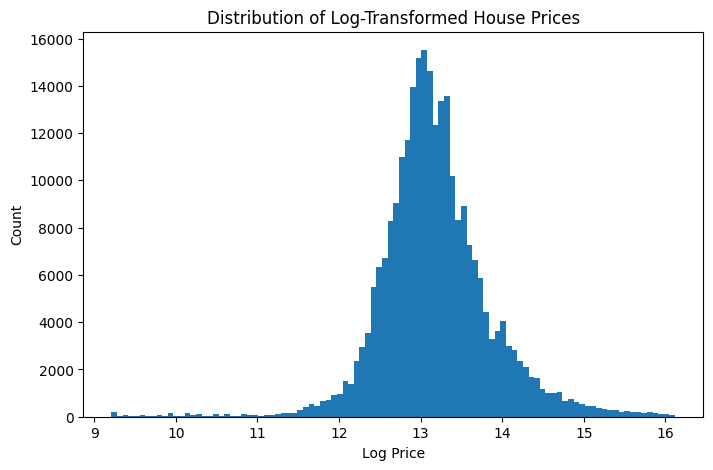

Saved: /content/drive/MyDrive/DS7010_HousePrices/outputs/figures/fig7_price_distribution.png
Saved: /content/drive/MyDrive/DS7010_HousePrices/outputs/figures/fig8_log_price_distribution.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"
OUT  = "/content/drive/MyDrive/DS7010_HousePrices/outputs"
FIGS = os.path.join(OUT, "figures")
os.makedirs(FIGS, exist_ok=True)

df = pd.read_csv(os.path.join(PROC, "train_2022_2023_imd_tfl_center.csv"))

# Raw price distribution
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=100)
plt.xlabel("Price (£)")
plt.ylabel("Count")
plt.title("Distribution of House Prices")
fig1 = os.path.join(FIGS, "fig7_price_distribution.png")
plt.savefig(fig1, dpi=200, bbox_inches="tight")
plt.show()

# Log price distribution
plt.figure(figsize=(8, 5))
plt.hist(df["log_price"], bins=100)
plt.xlabel("Log Price")
plt.ylabel("Count")
plt.title("Distribution of Log-Transformed House Prices")
fig2 = os.path.join(FIGS, "fig8_log_price_distribution.png")
plt.savefig(fig2, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig1)
print("Saved:", fig2)

In [ ]:
import os
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import ParameterGrid


# 1. Load data
#  ############
PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"

train_full = pd.read_csv(os.path.join(PROC, "train_2022_2023_imd_tfl_center.csv"))
test = pd.read_csv(os.path.join(PROC, "test_2024_imd_tfl_center.csv"))

# final feature set
num_features = ["lat", "lon", "month", "imd_decile", "dist_station_km", "dist_center_km"]
cat_features = ["property_type", "new_build_flag", "tenure_type"]
all_features = num_features + cat_features

# inner split for tuning:
# 2022 -> train_inner
# 2023 -> val_inner
train_inner = train_full[train_full["year"] == 2022].copy()
val_inner   = train_full[train_full["year"] == 2023].copy()

X_train_inner = train_inner[all_features]
y_train_inner = train_inner["log_price"]

X_val_inner = val_inner[all_features]
y_val_inner = val_inner["log_price"]

# full train for final fit
X_train_full = train_full[all_features]
y_train_full = train_full["log_price"]

X_test = test[all_features]
y_test = test["log_price"]

####
# 2. Preprocessing
####
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

# #####
# 3. Metrics
# -------
def metrics_from_log(y_log_true, y_log_pred):
    true_price = np.exp(y_log_true)
    pred_price = np.exp(y_log_pred)

    mae = mean_absolute_error(true_price, pred_price)
    rmse = np.sqrt(mean_squared_error(true_price, pred_price))
    r2 = r2_score(true_price, pred_price)
    medae = median_absolute_error(true_price, pred_price)
    within10 = np.mean(np.abs(pred_price - true_price) <= 0.10 * true_price) * 100

    return {
        "MAE (£)": mae,
        "RMSE (£)": rmse,
        "R2": r2,
        "MedianAE (£)": medae,
        "Within10%": within10
    }

def fit_and_eval(model, X_train, y_train, X_eval, y_eval):
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_eval)
    return pipe, metrics_from_log(y_eval, pred_log)

#  --------
# 4. Baseline models
#  ---------------
baseline_models = {
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=5000),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=5
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=10,
        max_iter=300,
        random_state=42
    )
}

print("Running baseline models on 2024 test set...\n")
baseline_results = []

for name, model in baseline_models.items():
    _, m = fit_and_eval(model, X_train_full, y_train_full, X_test, y_test)
    row = {"Model": name, "Version": "Baseline"}
    row.update(m)
    baseline_results.append(row)
    print(name, m)

# =========================
# 5. Parameter grids for tuning
# ----------------------------
param_grids = {
    "ElasticNet": {
        "alpha": [0.0001, 0.001, 0.01, 0.05],
        "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    "RandomForest": {
        "n_estimators": [150, 250],
        "max_depth": [None, 20, 40],
        "min_samples_leaf": [1, 3, 5, 10],
        "max_features": ["sqrt", 0.5, 0.8]
    },
    "HistGradientBoosting": {
        "learning_rate": [0.03, 0.05, 0.08],
        "max_depth": [6, 8, 10, 12],
        "max_iter": [200, 300, 500],
        "min_samples_leaf": [20, 50, 100]
    }
}

# =========================
# 6. Tuning function
# ----------------------
def make_model(model_name, params):
    if model_name == "ElasticNet":
        return ElasticNet(
            alpha=params["alpha"],
            l1_ratio=params["l1_ratio"],
            random_state=42,
            max_iter=5000
        )

    elif model_name == "RandomForest":
        return RandomForestRegressor(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            max_features=params["max_features"],
            random_state=42,
            n_jobs=-1
        )

    elif model_name == "HistGradientBoosting":
        return HistGradientBoostingRegressor(
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            max_iter=params["max_iter"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=42
        )

def tune_model(model_name, grid):
    print(f"\nTuning {model_name}...")
    best_params = None
    best_mae = np.inf

    for params in ParameterGrid(grid):
        model = make_model(model_name, params)
        _, val_metrics = fit_and_eval(model, X_train_inner, y_train_inner, X_val_inner, y_val_inner)

        if val_metrics["MAE (£)"] < best_mae:
            best_mae = val_metrics["MAE (£)"]
            best_params = params

    print("Best params:", best_params)
    print("Best validation MAE:", round(best_mae, 2))

    # retrain best on full 2022-2023 and test on 2024
    best_model = make_model(model_name, best_params)
    _, test_metrics = fit_and_eval(best_model, X_train_full, y_train_full, X_test, y_test)

    return best_params, test_metrics

# ===========
# 7. Tune all three
# =========================
tuned_results = []
best_params_store = {}

for model_name, grid in param_grids.items():
    best_params, test_metrics = tune_model(model_name, grid)
    best_params_store[model_name] = best_params

    row = {"Model": model_name, "Version": "Tuned"}
    row.update(test_metrics)
    tuned_results.append(row)

# =========================
# 8. Final comparison table
# =========================
results_df = pd.DataFrame(baseline_results + tuned_results)

# round nicely
results_df["MAE (£)"] = results_df["MAE (£)"].round(2)
results_df["RMSE (£)"] = results_df["RMSE (£)"].round(2)
results_df["R2"] = results_df["R2"].round(4)
results_df["MedianAE (£)"] = results_df["MedianAE (£)"].round(2)
results_df["Within10%"] = results_df["Within10%"].round(2)

print("\n================ FINAL COMPARISON ================\n")
print(results_df)

print("\n================ BEST PARAMETERS ================\n")
for k, v in best_params_store.items():
    print(k, ":", v)

# save results
out_path = os.path.join(PROC, "tuning_results_comparison.csv")
results_df.to_csv(out_path, index=False)
print("\nSaved results to:", out_path)


Running baseline models on 2024 test set...

ElasticNet {'MAE (£)': 253574.28731333604, 'RMSE (£)': np.float64(623153.313428089), 'R2': 0.2091113015773033, 'MedianAE (£)': np.float64(120989.18479516222), 'Within10%': np.float64(22.12751421944012)}
RandomForest {'MAE (£)': 192281.82507108187, 'RMSE (£)': np.float64(504103.52405850886), 'R2': 0.4824348573897843, 'MedianAE (£)': np.float64(80602.1504386884), 'Within10%': np.float64(33.41886180928474)}
HistGradientBoosting {'MAE (£)': 217327.58176402067, 'RMSE (£)': np.float64(546293.6565159378), 'R2': 0.3921759673045432, 'MedianAE (£)': np.float64(97203.42231373832), 'Within10%': np.float64(27.766832957325793)}

Tuning ElasticNet...
Best params: {'alpha': 0.0001, 'l1_ratio': 0.9}
Best validation MAE: 265902.23

Tuning RandomForest...
Best params: {'max_depth': 40, 'max_features': 0.5, 'min_samples_leaf': 3, 'n_estimators': 250}
Best validation MAE: 205955.76


In [ ]:
import os
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import ParameterGrid

# =========================
# 1. Load data
# ===============
PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"

train_full = pd.read_csv(os.path.join(PROC, "train_2022_2023_imd_tfl_center.csv"))
test = pd.read_csv(os.path.join(PROC, "test_2024_imd_tfl_center.csv"))

# Final feature set
num_features = ["lat", "lon", "month", "imd_decile", "dist_station_km", "dist_center_km"]
cat_features = ["property_type", "new_build_flag", "tenure_type"]
all_features = num_features + cat_features

# =========================
# 2. Split for fast tuning
# ======
train_2022 = train_full[train_full["year"] == 2022].copy()
val_2023 = train_full[train_full["year"] == 2023].copy()

# Use a smaller sample of 2022 for faster tuning
train_2022_sample = train_2022.sample(
    n=min(50000, len(train_2022)),
    random_state=42
).copy()

X_train_tune = train_2022_sample[all_features]
y_train_tune = train_2022_sample["log_price"]

X_val = val_2023[all_features]
y_val = val_2023["log_price"]

# Full train for final refit
X_train_full = train_full[all_features]
y_train_full = train_full["log_price"]

X_test = test[all_features]
y_test = test["log_price"]

# -----------------------
# 3. Preprocessing

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)


# 4. Metrics function
# =========================
def metrics_from_log(y_log_true, y_log_pred):
    true_price = np.exp(y_log_true)
    pred_price = np.exp(y_log_pred)

    mae = mean_absolute_error(true_price, pred_price)
    rmse = np.sqrt(mean_squared_error(true_price, pred_price))
    r2 = r2_score(true_price, pred_price)
    medae = median_absolute_error(true_price, pred_price)
    within10 = np.mean(np.abs(pred_price - true_price) <= 0.10 * true_price) * 100

    return {
        "MAE (£)": mae,
        "RMSE (£)": rmse,
        "R2": r2,
        "MedianAE (£)": medae,
        "Within10%": within10
    }

def fit_and_eval(model, X_train, y_train, X_eval, y_eval):
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_eval)
    return pipe, metrics_from_log(y_eval, pred_log)


# 5. Baseline models
# =========================
baseline_models = {
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=5000),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=5
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=10,
        max_iter=300,
        random_state=42
    )
}

print("Running baseline models on 2024 test set...\n")
baseline_results = []

for name, model in baseline_models.items():
    _, m = fit_and_eval(model, X_train_full, y_train_full, X_test, y_test)
    row = {"Model": name, "Version": "Baseline"}
    row.update(m)
    baseline_results.append(row)
    print(name, m)

 #----------
# 6. Small, fast tuning grids
# =========================
param_grids = {
    "ElasticNet": {
        "alpha": [0.0005, 0.001, 0.01],
        "l1_ratio": [0.3, 0.5, 0.7]
    },
    "RandomForest": {
        "n_estimators": [100, 150],
        "max_depth": [20, None],
        "min_samples_leaf": [3, 5],
        "max_features": ["sqrt", 0.8]
    },
    "HistGradientBoosting": {
        "learning_rate": [0.03, 0.05],
        "max_depth": [8, 10],
        "max_iter": [200, 300],
        "min_samples_leaf": [20, 50]
    }
}

# -----------------
# 7. Model factory
# =========================
def make_model(model_name, params):
    if model_name == "ElasticNet":
        return ElasticNet(
            alpha=params["alpha"],
            l1_ratio=params["l1_ratio"],
            random_state=42,
            max_iter=5000
        )

    elif model_name == "RandomForest":
        return RandomForestRegressor(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            max_features=params["max_features"],
            random_state=42,
            n_jobs=-1
        )

    elif model_name == "HistGradientBoosting":
        return HistGradientBoostingRegressor(
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            max_iter=params["max_iter"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=42
        )

# -------
# 8. Tune each model on 2022 sample -> validate on 2023
# =========================
def tune_model(model_name, grid):
    print(f"\nTuning {model_name}...")
    best_params = None
    best_val_mae = np.inf

    for params in ParameterGrid(grid):
        model = make_model(model_name, params)
        _, val_metrics = fit_and_eval(model, X_train_tune, y_train_tune, X_val, y_val)

        if val_metrics["MAE (£)"] < best_val_mae:
            best_val_mae = val_metrics["MAE (£)"]
            best_params = params

    print("Best params:", best_params)
    print("Best validation MAE:", round(best_val_mae, 2))

    # Refit best model on full 2022-2023, then test on 2024
    best_model = make_model(model_name, best_params)
    _, test_metrics = fit_and_eval(best_model, X_train_full, y_train_full, X_test, y_test)

    return best_params, test_metrics

tuned_results = []
best_params_store = {}

for model_name, grid in param_grids.items():
    best_params, test_metrics = tune_model(model_name, grid)
    best_params_store[model_name] = best_params

    row = {"Model": model_name, "Version": "Tuned"}
    row.update(test_metrics)
    tuned_results.append(row)

#  ----------------
# 9. Final comparison
# =========================
results_df = pd.DataFrame(baseline_results + tuned_results)

results_df["MAE (£)"] = results_df["MAE (£)"].round(2)
results_df["RMSE (£)"] = results_df["RMSE (£)"].round(2)
results_df["R2"] = results_df["R2"].round(4)
results_df["MedianAE (£)"] = results_df["MedianAE (£)"].round(2)
results_df["Within10%"] = results_df["Within10%"].round(2)

print("\n================ FINAL COMPARISON ================\n")
print(results_df)

print("\n================ BEST PARAMETERS ================\n")
for k, v in best_params_store.items():
    print(k, ":", v)

# Save results
out_path = os.path.join(PROC, "fast_tuning_results_comparison.csv")
results_df.to_csv(out_path, index=False)
print("\nSaved results to:", out_path)

Running baseline models on 2024 test set...

ElasticNet {'MAE (£)': 253574.28731333604, 'RMSE (£)': np.float64(623153.313428089), 'R2': 0.2091113015773033, 'MedianAE (£)': np.float64(120989.18479516222), 'Within10%': np.float64(22.12751421944012)}
RandomForest {'MAE (£)': 192281.82507108184, 'RMSE (£)': np.float64(504103.52405850886), 'R2': 0.4824348573897843, 'MedianAE (£)': np.float64(80602.15043868881), 'Within10%': np.float64(33.41886180928474)}
HistGradientBoosting {'MAE (£)': 217327.58176402067, 'RMSE (£)': np.float64(546293.6565159378), 'R2': 0.3921759673045432, 'MedianAE (£)': np.float64(97203.42231373832), 'Within10%': np.float64(27.766832957325793)}

Tuning ElasticNet...
Best params: {'alpha': 0.0005, 'l1_ratio': 0.7}
Best validation MAE: 266108.04

Tuning RandomForest...
Best params: {'max_depth': 20, 'max_features': 0.8, 'min_samples_leaf': 3, 'n_estimators': 150}
Best validation MAE: 219303.95

Tuning HistGradientBoosting...
Best params: {'learning_rate': 0.05, 'max_depth'

In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/DS7010_HousePrices/data/processed/train_2022_2023_imd_tfl_center.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/DS7010_HousePrices/data/processed/test_2024_imd_tfl_center.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
 import pandas as pd
from google.colab import files

# Paths
train_path = '/content/drive/MyDrive/DS7010_HousePrices/data/processed/train_2022_2023_imd_tfl_center.csv'
test_path = '/content/drive/MyDrive/DS7010_HousePrices/data/processed/test_2024_imd_tfl_center.csv'
combined_path = '/content/drive/MyDrive/DS7010_HousePrices/data/processed/final_cleaned_london_house_prices.csv'

# Load existing processed files
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Create combined cleaned dataset
combined_df = pd.concat([train_df, test_df], ignore_index=True)

# Save combined file
combined_df.to_csv(combined_path, index=False)

print("Saved combined dataset to:")
print(combined_path)



Saved combined dataset to:
/content/drive/MyDrive/DS7010_HousePrices/data/processed/final_cleaned_london_house_prices.csv


In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/DS7010_HousePrices/data/processed/final_cleaned_london_house_prices.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

PROC = "/content/drive/MyDrive/DS7010_HousePrices/data/processed"
print(os.listdir(PROC))

['ppd_2022_2024_min.csv', 'onspd_min.csv', 'ppd_onspd_2022_2024.csv', 'ppd_london_2022_2024.csv', 'ppd_london_bbox_2022_2024.csv', 'london_model_ready_2022_2024.csv', 'train_2022_2023.csv', 'test_2024.csv', 'train_2022_2023_imd.csv', 'test_2024_imd.csv', 'train_2022_2023_imd_tfl.csv', 'test_2024_imd_tfl.csv', 'train_2022_2023_imd_tfl_center.csv', 'test_2024_imd_tfl_center.csv', 'tuning_results_comparison.csv', 'fast_tuning_results_comparison.csv', 'final_cleaned_london_house_prices.csv']
